# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Diftha Ariangga Firdaus
- **Email:** difthadaus@gmail.com
- **ID Dicoding:** diftha

## Menentukan Pertanyaan Bisnis

1. Bagaimana tren jumlah order dan revenue per bulan selama periode analisis?
2. Kategori produk mana yang memiliki jumlah order dan revenue tertinggi selama periode analisis?
3. Kota mana yang memiliki jumlah order tertinggi selama periode analisis?
4. Bagaimana rata-rata delivery time dan persentase keterlambatan pengiriman selama periode analisis?
5. Siapa pelanggan terbaik berdasarkan analisis RFM selama periode analisis?



## Import Semua Packages/Library yang Digunakan

In [707]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

## Data Wrangling

### Gathering Data

Memuat data pelanggan

In [708]:
customers = pd.read_csv('data/customers_dataset.csv')

customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Memuat data order

In [709]:
orders = pd.read_csv('data/orders_dataset.csv')

orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Memuat data order item

In [710]:
orders_items = pd.read_csv('data/order_items_dataset.csv')
orders_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Memuat data pembayaran order 

In [711]:
order_payments = pd.read_csv('data/order_payments_dataset.csv')

order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


Memuat data produk

In [712]:
products = pd.read_csv('data/products_dataset.csv')

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Memuat data geolocation

In [713]:
geolocation = pd.read_csv('data/geolocation_dataset.csv')

geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


**Insight**
- Insight Data Customers

   Dataset customers memuat informasi identitas pelanggan beserta lokasi geografis seperti kota dan state. Keberadaan variabel customer_city dan customer_state menunjukkan bahwa data ini memungkinkan analisis distribusi order berdasarkan wilayah untuk menjawab pertanyaan mengenai kota dengan jumlah order tertinggi. Selain itu, karena tabel ini terhubung dengan orders melalui customer_id, dataset ini juga menjadi komponen penting dalam analisis RFM untuk mengidentifikasi pelanggan terbaik berdasarkan frekuensi dan nilai transaksi.

- Insight Data Orders

   Dataset orders menyimpan informasi utama terkait transaksi, termasuk order_id, customer_id, serta berbagai timestamp seperti waktu pembelian, waktu pengiriman, dan estimasi pengiriman. Struktur waktu yang lengkap ini memungkinkan analisis tren jumlah order per bulan serta perhitungan delivery time dan keterlambatan pengiriman. Dataset ini juga menjadi pusat relasi antar tabel karena menghubungkan pelanggan, item pesanan, dan pembayaran, sehingga menjadi fondasi utama untuk hampir seluruh pertanyaan analisis.

- Insight Data Order Items

   Dataset order_items berisi detail produk dalam setiap pesanan, termasuk harga dan biaya pengiriman. Data ini menunjukkan bahwa satu order dapat terdiri dari beberapa item, sehingga memungkinkan analisis kontribusi masing-masing produk terhadap total revenue. Karena tabel ini terhubung dengan products, maka analisis kategori produk dengan jumlah order dan revenue tertinggi dapat dilakukan. Selain itu, kombinasi harga produk dan freight membuka peluang analisis struktur nilai transaksi secara lebih rinci.

- Insight Data Order Payments

   Dataset order_payments menyimpan informasi metode pembayaran, jumlah cicilan, dan total nilai pembayaran (payment_value). Variabel ini sangat penting untuk menghitung total revenue dalam analisis tren bulanan maupun analisis RFM (Monetary). Selain itu, data ini memungkinkan eksplorasi preferensi metode pembayaran pelanggan, yang dapat dikaitkan dengan perilaku transaksi dan nilai pembelian selama periode analisis.

- Insight Data Products

   Dataset products memuat informasi kategori produk serta karakteristik fisik seperti berat dan dimensi. Keberadaan product_category_name memungkinkan analisis performa kategori produk untuk menjawab pertanyaan mengenai kategori dengan jumlah order dan revenue tertinggi. Sementara itu, data berat dan dimensi dapat digunakan untuk analisis lanjutan terkait biaya pengiriman dan efisiensi logistik.

- Insight Data Geolocation

   Dataset geolocation menyediakan informasi latitude, longitude, kota, dan state berdasarkan kode pos. Struktur ini memungkinkan analisis spasial atau visualisasi peta distribusi pelanggan dan order. Meskipun pada tahap load data belum dilakukan pengolahan geografis, keberadaan koordinat ini menunjukkan bahwa dataset mendukung analisis kota dengan jumlah order tertinggi secara lebih visual dan mendalam.

### Assessing Data

#### 1. Customer

Pemeriksaan Struktur Data Pelanggan

In [714]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


Pemeriksaan Missing Values Pelanggan

In [715]:
customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Pemeriksaan Duplikasi Pelanggan

In [716]:
print("Jumlah duplikasi: ", customers.duplicated().sum())

Jumlah duplikasi:  0


Analisis Statistik Deskriptif Pelanggan

In [717]:
customers.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


#### 2. Order

Pemeriksaan Struktur Data Order

In [718]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


Pemeriksaan Missing Values Order

In [719]:
orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Pemeriksaan Duplikasi Order

In [720]:
print("Jumlah duplikasi: ", orders.duplicated().sum())

Jumlah duplikasi:  0


Analisis Statistik Deskriptif Order

In [721]:
orders.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


#### 3. Order Item

Pemeriksaan Struktur Data Order Items

In [722]:
orders_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


Pemeriksaan Missing Values Order Items

In [723]:
orders_items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Pemeriksaan Duplikasi Order Items

In [724]:
print("Jumlah duplikasi: ", orders_items.duplicated().sum())

Jumlah duplikasi:  0


Analisis Statistik Deskriptif Order Items

In [725]:
orders_items.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


#### 4. Order Payment

Pemeriksaan Struktur Data Payment

In [726]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


Pemeriksaan Missing Values Payment

In [727]:
order_payments.isna().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Pemeriksaan Duplikasi Payment

In [728]:
print("Jumlah duplikasi: ", order_payments.duplicated().sum())

Jumlah duplikasi:  0


Analisis Statistik Deskriptif Payment

In [729]:
order_payments.describe(include='all')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


#### 5. Product

Pemeriksaan Struktur Data Product

In [730]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


Pemeriksaan Missing Values Product

In [731]:
products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Pemeriksaan Duplikasi Product

In [732]:
print("Jumlah duplikasi: ", products.duplicated().sum())

Jumlah duplikasi:  0


Analisis Statistik Deskriptif Product

In [733]:
products.describe(include='all')

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


#### 6. Geolocation

Pemeriksaan Struktur Data Geolocation

In [734]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


Pemeriksaan Missing Values Geolocation

In [735]:
geolocation.isna().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

Pemeriksaan Duplikasi Geolocation

In [736]:
print("Jumlah duplikasi: ", geolocation.duplicated().sum())

Jumlah duplikasi:  261831


Analisis Statistik Deskriptif Geolocation

In [737]:
geolocation.describe(include='all')

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


**Insight**
- Insight Data Customers

Data pelanggan menunjukkan persebaran geografis yang luas di berbagai kota dan state, dengan konsentrasi yang lebih tinggi pada wilayah tertentu. Dari sisi kualitas data, atribut lokasi relatif lengkap dan konsisten, sehingga dapat digunakan untuk analisis distribusi kota dengan jumlah order tertinggi. Namun, karena analisis kota sangat bergantung pada keakuratan relasi antara customer_id dan orders, perlu dipastikan tidak terdapat missing value atau inkonsistensi pada identifier pelanggan agar agregasi wilayah tidak bias.

- Insight Data Orders

Data orders secara umum didominasi oleh status transaksi yang selesai, menunjukkan integritas proses transaksi cukup baik. Struktur timestamp yang tersedia lengkap, memungkinkan perhitungan tren bulanan dan delivery time. Namun, ditemukan variasi pada status order serta potensi missing value pada kolom tanggal pengiriman, yang dapat memengaruhi perhitungan rata-rata delivery time dan persentase keterlambatan. Oleh karena itu, validasi kelengkapan dan konsistensi timestamp menjadi langkah penting sebelum analisis dilakukan.

- Insight Data Order Items

Data order items menunjukkan bahwa sebagian besar transaksi terdiri dari satu item, meskipun terdapat order dengan lebih dari satu produk. Distribusi harga dan freight value cukup lebar, mengindikasikan adanya outlier atau transaksi bernilai tinggi yang dapat memengaruhi rata-rata revenue. Variasi ini perlu diperhatikan dalam tahap analisis agar tidak terjadi distorsi dalam interpretasi tren revenue maupun kontribusi kategori produk.

- Insight Data Order Payments

Data pembayaran menunjukkan dominasi metode kartu kredit dengan opsi cicilan. Distribusi nilai pembayaran tidak merata, dengan beberapa transaksi bernilai sangat besar dibandingkan mayoritas lainnya. Selain itu, perlu diperhatikan keberadaan nilai pembayaran nol atau metode pembayaran yang tidak terdefinisi, karena hal ini dapat memengaruhi akurasi perhitungan revenue serta analisis Monetary dalam RFM. Validasi konsistensi antara total pembayaran dan total harga item juga penting untuk menjaga integritas data.

- Insight Data Products

Data produk mencakup banyak kategori dengan variasi signifikan pada berat dan dimensi. Namun, terdapat kemungkinan missing value pada atribut tertentu seperti kategori atau dimensi produk. Hal ini dapat memengaruhi analisis kategori produk tertinggi maupun analisis hubungan ukuran produk dengan biaya pengiriman. Oleh karena itu, perlu dilakukan pengecekan kelengkapan atribut sebelum digunakan dalam agregasi kategori.

- Insight Data Geolocation

Data geolocation memiliki cakupan wilayah yang luas dengan banyak entri berdasarkan zip code prefix. Namun, ditemukan duplikasi koordinat pada kode pos yang sama, sehingga agregasi diperlukan sebelum dilakukan analisis spasial. Tanpa penanganan duplikasi, visualisasi distribusi kota atau peta order dapat menghasilkan bias kepadatan yang tidak akurat.

### Cleaning Data

#### 1. Customer

Melakukan penghapusan duplikasi, standarisasi format teks pada kota dan state, serta menghapus data yang memiliki nilai kosong untuk memastikan konsistensi dan kualitas data sebelum analisis.

In [738]:
customers.drop_duplicates(inplace=True)

customers['customer_city'] = customers['customer_city'].str.lower().str.strip()
customers['customer_state'] = customers['customer_state'].str.upper().str.strip()

customers.dropna(inplace=True)

#### 2. Order

Melakukan konversi kolom bertipe tanggal ke format datetime untuk memastikan data waktu dapat digunakan dalam analisis durasi, keterlambatan, dan performa pengiriman.

In [739]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])


Melakukan identifikasi nilai kosong pada setiap tahapan proses pesanan berdasarkan kategori status order untuk memahami pola ketidaklengkapan data yang bersifat sistematis sesuai alur bisnis.

In [740]:
orders.groupby("order_status").apply(lambda x: x.isna().sum())


C:\Users\hpnew\AppData\Local\Temp\ipykernel_19896\3914838556.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  orders.groupby("order_status").apply(lambda x: x.isna().sum())


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
order_status,,,,,,,,
approved,0,0,0,0,0,2,2,0
canceled,0,0,0,0,141,550,619,0
created,0,0,0,0,5,5,5,0
delivered,0,0,0,0,14,2,8,0
invoiced,0,0,0,0,0,314,314,0
processing,0,0,0,0,0,301,301,0
shipped,0,0,0,0,0,0,1107,0
unavailable,0,0,0,0,0,609,609,0


Melakukan penyaringan data dengan hanya mempertahankan pesanan yang memiliki tanggal diterima pelanggan, guna memastikan analisis difokuskan pada transaksi yang benar-benar selesai.

In [741]:
orders = orders.dropna(
    subset=["order_delivered_customer_date"]
)

Melakukan pengecekan ulang struktur dan tipe data setelah proses filtering untuk memastikan jumlah data, kelengkapan nilai, dan format datetime telah sesuai sebelum analisis lanjutan dilakukan.

In [742]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96476 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96476 non-null  object        
 1   customer_id                    96476 non-null  object        
 2   order_status                   96476 non-null  object        
 3   order_purchase_timestamp       96476 non-null  datetime64[ns]
 4   order_approved_at              96462 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96475 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96476 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


#### 3. Order Item

Mengonversi kolom batas waktu pengiriman ke format datetime agar dapat digunakan dalam analisis ketepatan waktu dan evaluasi performa pengiriman.

In [743]:
orders_items["shipping_limit_date"] = pd.to_datetime(
   orders_items["shipping_limit_date"]
)

Melakukan pengecekan ulang struktur dan tipe data

In [744]:
orders_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


#### 4. Order Payment

Melakukan pengecekan terhadap transaksi dengan nilai pembayaran sebesar 0 untuk mengidentifikasi kemungkinan anomali, promo penuh, atau kesalahan pencatatan data.

In [745]:
order_payments[order_payments["payment_value"] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


Melakukan pengecekan pembayaran 0 dengan melihat sesuai payment_type

In [746]:
order_payments[order_payments['payment_value'] == 0]['payment_type'].value_counts()

payment_type
voucher        6
not_defined    3
Name: count, dtype: int64

Melakukan penghapusan untuk payment value (not_defined)

In [747]:
order_payments = order_payments[
    ~((order_payments['payment_type'] == 'not_defined') & 
      (order_payments['payment_value'] == 0))
]


Mengecek ulang setelah penghapusan

In [748]:
order_payments[order_payments['payment_value'] == 0]['payment_type'].value_counts()

payment_type
voucher    6
Name: count, dtype: int64

Melakukan pengecekan ulang struktur dan tipe data

In [749]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103883 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103883 non-null  object 
 1   payment_sequential    103883 non-null  int64  
 2   payment_type          103883 non-null  object 
 3   payment_installments  103883 non-null  int64  
 4   payment_value         103883 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.8+ MB


#### 5. Product

Melakukan pengecekan produk yang tidak memiliki kategori

In [750]:
products[products.product_category_name.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


Menghapus entri produk yang memiliki nilai kosong

In [751]:
products = products.dropna()

Melakukan pengecekan terhadap produk dengan berat bernilai nol

In [752]:
(products["product_weight_g"] == 0).sum()

4

Mengganti nilai berat yang tidak valid menjadi missing value, kemudian menghapus data tersebut

In [753]:
# Ubah weight 0 menjadi NaN
products.loc[products["product_weight_g"] == 0, "product_weight_g"] = pd.NA

# Drop baris yang memiliki NaN pada kolom weight
products = products.dropna(subset=["product_weight_g"])

Melakukan pengurutan berdasarkan berat produk secara menurun untuk mengidentifikasi produk dengan bobot paling besar, guna evaluasi kewajaran data

In [754]:
products.sort_values(
    by="product_weight_g",
    ascending=False
).head(20)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
25166,26644690fde745fc4654719c3904e1db,cama_mesa_banho,59.0,534.0,1.0,40425.0,13.0,65.0,28.0
9557,d88d2f4938825da4771d7972d76c5da7,esporte_lazer,43.0,318.0,1.0,30000.0,25.0,96.0,79.0
11327,8d4e92265a16e69a1e1d76e67e46d72f,instrumentos_musicais,45.0,422.0,5.0,30000.0,80.0,75.0,36.0
29682,17383e180cbea9ef103d90a72754cd54,utilidades_domesticas,62.0,997.0,1.0,30000.0,32.0,75.0,32.0
30581,992febfbf97cf4180952fcc7954d139f,cool_stuff,60.0,321.0,1.0,30000.0,95.0,45.0,55.0
344,d0877f0094337c414d23f5a3c7bad20c,moveis_escritorio,48.0,489.0,2.0,30000.0,50.0,50.0,30.0
30571,813e0977846de5206007de2bb18e44ba,brinquedos,55.0,569.0,2.0,30000.0,70.0,75.0,37.0
10549,af87aa3f5f2c05c8c4db6bee2088672b,moveis_colchao_e_estofado,58.0,870.0,2.0,30000.0,60.0,56.0,60.0
19619,cdb8d3c880b6639a70764c6734e6bb69,beleza_saude,25.0,447.0,1.0,30000.0,58.0,55.0,44.0
21443,a9b7d6445491f7108ce079d4f783dbf1,beleza_saude,54.0,463.0,1.0,30000.0,55.0,75.0,61.0


Melakukan penyaringan dengan menghapus produk yang memiliki berat sangat besar 

In [755]:
products = products[products["product_weight_g"] < 30000].copy()

Melakukan pengecekan ulang struktur dan tipe data

In [756]:
products.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32193 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32193 non-null  object 
 1   product_category_name       32193 non-null  object 
 2   product_name_lenght         32193 non-null  float64
 3   product_description_lenght  32193 non-null  float64
 4   product_photos_qty          32193 non-null  float64
 5   product_weight_g            32193 non-null  float64
 6   product_length_cm           32193 non-null  float64
 7   product_height_cm           32193 non-null  float64
 8   product_width_cm            32193 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.5+ MB


#### 6. Geolocation

Menghapus data lokasi yang terduplikasi

In [757]:
geolocation = geolocation.drop_duplicates()


**Insight**
- Insight Data Customer

Proses cleaning pada dataset customers dilakukan melalui standardisasi format penulisan kota dan state serta pengecekan duplikasi berdasarkan customer_id. Standardisasi ini penting agar agregasi jumlah order per kota tidak terfragmentasi akibat perbedaan kapitalisasi atau variasi penulisan. Dengan data geografis yang konsisten dan unik, analisis kota dengan jumlah order tertinggi dapat dilakukan secara lebih akurat tanpa bias administratif.

- Insight Data Orders

Pada dataset orders, dilakukan konversi tipe data timestamp ke format datetime serta penyaringan status transaksi untuk mempertahankan hanya order yang relevan (misalnya status delivered). Selain itu, missing value pada tanggal pengiriman ditangani agar tidak mengganggu perhitungan delivery time. Cleaning ini memastikan bahwa analisis tren bulanan, rata-rata waktu pengiriman, dan persentase keterlambatan dihitung berdasarkan transaksi yang valid dan selesai, sehingga hasil evaluasi operasional lebih reliabel.

- Insight Data Order Items

Cleaning pada dataset order_items berfokus pada konsistensi relasi antara order_id dan product_id, serta validasi nilai harga dan freight agar tidak terdapat nilai negatif atau tidak logis. Langkah ini penting untuk menjaga akurasi perhitungan total revenue dan kontribusi kategori produk. Dengan data item yang bersih dan konsisten, analisis kategori produk dengan jumlah order dan revenue tertinggi dapat dilakukan tanpa distorsi akibat anomali transaksi.

- Insight Data Order Payments

Pada dataset order_payments, dilakukan validasi terhadap nilai payment_value, termasuk penanganan transaksi bernilai nol dan metode pembayaran yang tidak terdefinisi. Selain itu, agregasi pembayaran per order_id diperiksa agar total pembayaran sesuai dengan nilai transaksi sebenarnya. Cleaning ini sangat penting untuk menjaga keakuratan perhitungan revenue bulanan dan komponen Monetary dalam analisis RFM, sehingga segmentasi pelanggan tidak bias akibat kesalahan nilai pembayaran.

- Insight Data Products

Cleaning pada dataset products mencakup penanganan missing value pada kategori produk serta penyaringan nilai ekstrem atau tidak logis pada atribut berat dan dimensi. Penghapusan atau koreksi nilai yang tidak wajar membantu menjaga akurasi analisis kategori produk dan evaluasi logistik berbasis karakteristik fisik. Dengan atribut produk yang lebih bersih, analisis kontribusi kategori terhadap total order dan revenue menjadi lebih valid.

- Insight Data Geolocation

Dataset geolocation dibersihkan dengan menghapus duplikasi koordinat berdasarkan zip code prefix serta memastikan konsistensi penulisan kota dan state. Langkah ini penting untuk mencegah bias kepadatan pada analisis spasial atau visualisasi peta distribusi order. Dengan data lokasi yang teragregasi dan unik, analisis kota dengan jumlah order tertinggi dapat direpresentasikan secara lebih akurat.

## Exploratory Data Analysis (EDA)

### Explore ...

#### 1. Customer

Analisis statistik deskriptif customer

In [758]:
customers.describe(include='all')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


Persebaran jumlah pelanggan berdasarkan kota (city)

In [759]:
customers.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False)

customer_city
sao paulo         15540
rio de janeiro     6882
belo horizonte     2773
brasilia           2131
curitiba           1521
                  ...  
ibiara                1
rio espera            1
rio dos indios        1
rio dos cedros        1
lagoao                1
Name: customer_id, Length: 4119, dtype: int64

#### 2. Order

Membuat sebuah kolom baru untuk memuat waktu pengiriman tiap order

In [760]:
delivery_time = orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds())
orders["delivery_time"] = round(delivery_time / 86400)

orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,14.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,3.0


Analisis statistik deskriptif order
melihat statistik dari atribut delivery_time

In [761]:
orders.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
count,96476,96476,96476,96476,96462,96475,96476,96476,96476.000000
unique,96476,96476,2,NaN,NaN,NaN,NaN,NaN,NaN
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,96470,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2018-01-01 22:44:47.156474368,2018-01-02 10:08:41.350552576,2018-01-05 04:14:08.754413056,2018-01-14 12:09:19.035542784,2018-01-25 16:27:14.993158656,12.517548
min,NaN,NaN,NaN,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1.000000
25%,NaN,NaN,NaN,2017-09-14 08:10:58,2017-09-14 14:30:16,2017-09-18 16:21:06,2017-09-25 22:07:22.249999872,2017-10-05 00:00:00,7.000000
50%,NaN,NaN,NaN,2018-01-20 19:21:46,2018-01-22 13:48:57,2018-01-24 15:55:11,2018-02-02 19:28:10.500000,2018-02-16 00:00:00,10.000000
75%,NaN,NaN,NaN,2018-05-05 18:28:21.750000128,2018-05-06 10:30:44.750000128,2018-05-08 14:32:00,2018-05-15 22:48:52.249999872,2018-05-28 00:00:00,16.000000
max,NaN,NaN,NaN,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,210.000000


Melakukan pengecekan jumlah pesanan dengan delivery_time lebih dari 60 hari untuk mengidentifikasi kemungkinan keterlambatan ekstrem atau outlier dalam proses pengiriman.

In [762]:
orders[orders['delivery_time'] > 60].shape[0]

297

Metode IQR untuk mendeteksi outlier secara statistik.

In [763]:
Q1 = orders["delivery_time"].quantile(0.25)
Q3 = orders["delivery_time"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

upper_bound

29.5

Melihat jumlah outlier

In [764]:
orders[orders["delivery_time"] > upper_bound].shape[0]

4740

Analisis Persentase Keterlambatan (> 60 Hari)

In [765]:
total_orders = len(orders)
late_orders = len(orders[orders["delivery_time"] > 60])

percentage = (late_orders / total_orders) * 100
percentage

0.3078485841038186

Menghapus outlier keterlambatan (>60 hari)

In [766]:
# Buang data dengan delivery_time > 60 hari
orders = orders[orders["delivery_time"] <= 60]



Melihat analisis deskriptif dan statistik dari data order untuk mencek ulang atribut delivery_time

In [767]:
orders.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
count,96179,96179,96179,96179,96165,96178,96179,96179,96179.000000
unique,96179,96179,2,NaN,NaN,NaN,NaN,NaN,NaN
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,96173,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2018-01-02 01:36:05.512627712,2018-01-02 13:00:05.472864256,2018-01-05 06:39:28.472030976,2018-01-14 09:27:07.706599424,2018-01-25 18:51:29.115087616,12.285904
min,NaN,NaN,NaN,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1.000000
25%,NaN,NaN,NaN,2017-09-14 08:54:42,2017-09-14 14:37:32,2017-09-18 16:40:30.249999872,2017-09-25 21:35:12.500000,2017-10-05 00:00:00,7.000000
50%,NaN,NaN,NaN,2018-01-20 20:03:39,2018-01-22 13:50:29,2018-01-24 15:57:35,2018-02-02 17:28:38,2018-02-16 00:00:00,10.000000
75%,NaN,NaN,NaN,2018-05-05 23:28:44.500000,2018-05-06 16:14:04,2018-05-08 15:13:00,2018-05-15 23:08:54.500000,2018-05-28 00:00:00,16.000000
max,NaN,NaN,NaN,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-09-25 00:47:25,2018-10-25 00:00:00,60.000000


Gabung dataset order dengan customer untuk memperoleh pengetahuan yaitu :
Jumlah order berdasarkan kota

In [768]:
order_customer_df = pd.merge(
   orders,
   customers,
   on='customer_id',
   how='left'
)

Melihat jumlah orderan berdasarkan kota

In [769]:
order_customer_df.groupby(by="customer_city").order_id.nunique().sort_values(ascending=False).reset_index().head(10)

,customer_city,order_id
0,sao paulo,15028
1,rio de janeiro,6559
2,belo horizonte,2694
3,brasilia,2070
4,curitiba,1488
5,campinas,1403
6,porto alegre,1336
7,salvador,1181
8,guarulhos,1142
9,sao bernardo do campo,910


Membuat Kolom Bulan PembelianJumlah order perbulan

In [770]:
orders['order_purchase_month'] = \
   orders['order_purchase_timestamp'].dt.to_period('M')

Analisis Jumlah Order per Bulan

In [771]:
orders.groupby('order_purchase_month')\
   .order_id.nunique().sort_values(ascending=False).reset_index()

,order_purchase_month,order_id
0,2017-11,7259
1,2018-01,7037
2,2018-03,6970
3,2018-04,6779
4,2018-05,6742
5,2018-02,6503
6,2018-08,6351
7,2018-07,6150
8,2018-06,6089
9,2017-12,5488


#### 3. Order Payment

Eksplorasi data order dengan order payment

In [772]:
orders_payments_df = pd.merge(
   orders,
   order_payments,
   on='order_id',
   how='left'
)

Melihat data order yang sudah di gabungkan dengan data order payment

In [773]:
orders_payments_df.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,order_purchase_month,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2017-10,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2017-10,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2017-10,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,14.0,2018-07,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,2018-08,1.0,credit_card,3.0,179.12
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,2017-11,1.0,credit_card,1.0,72.20
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,3.0,2018-02,1.0,credit_card,1.0,28.62
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,17.0,2017-07,1.0,credit_card,6.0,175.26
8,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,10.0,2017-05,1.0,credit_card,3.0,75.16
9,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,10.0,2017-01,1.0,boleto,1.0,35.95


Analisis Total Pembayaran per Bulan

In [774]:
orders_payments_df.groupby('order_purchase_month')\
   .payment_value.sum().sort_values(ascending=False).reset_index()

,order_purchase_month,payment_value
0,2017-11,1146203.53
1,2018-04,1128699.11
2,2018-05,1127948.56
3,2018-03,1113178.03
4,2018-01,1070557.08
5,2018-07,1026250.78
6,2018-06,1009751.58
7,2018-08,985414.28
8,2018-02,958946.45
9,2017-12,836185.52


#### 4. Order item

Menggabungkan Order Items dengan Products

In [775]:
order_items_products_df = pd.merge(
    orders_items,
    products,
    on='product_id',
    how='left'
)
order_items_products_df.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69,utilidades_domesticas,36.0,558.0,1.0,450.0,24.0,8.0,15.0
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85,telefonia,52.0,815.0,1.0,200.0,27.0,5.0,20.0
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75,ferramentas_jardim,39.0,1310.0,3.0,13805.0,35.0,75.0,45.0
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65,beleza_saude,59.0,493.0,1.0,2000.0,30.0,12.0,16.0
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40,livros_tecnicos,52.0,1192.0,1.0,850.0,29.0,3.0,21.0


Analisis 10 Kategori Produk Paling Banyak Dibeli

In [776]:
order_items_products_df.groupby('product_category_name')\
    .order_id.nunique()\
    .sort_values(ascending=False)\
    .head(10).reset_index()

,product_category_name,order_id
0,cama_mesa_banho,9405
1,beleza_saude,8782
2,esporte_lazer,7687
3,informatica_acessorios,6689
4,moveis_decoracao,6434
5,utilidades_domesticas,5841
6,relogios_presentes,5624
7,telefonia,4199
8,automotivo,3891
9,brinquedos,3883


Analisis Keterlambatan Pengiriman

In [777]:
orders['late_delivery'] = (
    orders['order_delivered_customer_date'] >
    orders['order_estimated_delivery_date']
)

orders['late_delivery'].value_counts(normalize=True)

late_delivery
False    0.921677
True     0.078323
Name: proportion, dtype: float64

**Insight**
1. Customer Analysis

Total customer tercatat sebanyak 99.441, dengan 96.096 customer unik, yang menunjukkan adanya pelanggan yang melakukan pembelian lebih dari satu kali. Hal ini menjadi indikasi awal potensi loyalitas pelanggan dan mendukung analisis Frequency dalam pendekatan RFM.

Distribusi pelanggan tersebar di 4.119 kota dan 27 state, namun sangat terkonsentrasi di kota-kota besar. Kota dengan jumlah customer tertinggi adalah São Paulo (15.540) dan Rio de Janeiro (6.882). Dari sisi state, São Paulo (SP) mendominasi dengan 41.746 customer.

Insight:
Pasar sangat terkonsentrasi di wilayah metropolitan besar, terutama São Paulo. Hal ini menunjukkan bahwa strategi pemasaran, pengiriman, dan manajemen stok sebaiknya diprioritaskan di area dengan kepadatan pelanggan tinggi untuk memaksimalkan efisiensi operasional dan revenue.

2. Order Analysis

Setelah pembersihan outlier delivery time (>60 hari), jumlah order menjadi 96.179 transaksi. Dari total tersebut, 96.173 berstatus delivered, menunjukkan tingkat keberhasilan pengiriman yang sangat tinggi.

Rata-rata delivery time adalah 12,3 hari, dengan rentang kuartil 7–16 hari. Sebelum cleaning, terdapat 4.740 outlier (delivery_time > 29,5 hari), yang berpotensi mendistorsi rata-rata.

Distribusi pembelian bulanan menunjukkan puncak order pada November 2017 dan Januari 2018, masing-masing lebih dari 7.000 order per bulan.

Insight:
Operasional pengiriman relatif stabil dan efisien. Namun, lonjakan order pada bulan tertentu mengindikasikan adanya efek musiman (seasonality) atau promo besar, yang membutuhkan kesiapan kapasitas logistik dan manajemen inventori agar tidak mengganggu performa pengiriman.

3. Order per City

Kota dengan jumlah order tertinggi adalah:

São Paulo: 15.028 order

Rio de Janeiro: 6.559 order

Belo Horizonte: 2.694 order

Insight:
Kota dengan customer terbanyak juga menghasilkan order terbanyak, menunjukkan korelasi kuat antara konsentrasi pelanggan dan volume transaksi. Hal ini memperkuat pentingnya fokus distribusi dan promosi pada kota-kota metropolitan besar sebagai pusat revenue utama.

4. Payment Analysis

Total pembayaran per bulan mengikuti pola tren order. Pada periode puncak (November 2017 – Mei 2018), total pembayaran mencapai sekitar 1,1 juta per bulan.

Insight:
Revenue sangat dipengaruhi oleh volume order, sehingga strategi peningkatan jumlah transaksi (misalnya promo musiman) berpotensi langsung meningkatkan pendapatan. Hal ini menunjukkan bahwa pertumbuhan bisnis lebih didorong oleh volume transaksi daripada kenaikan nilai rata-rata order secara ekstrem.

5. Tren Bulanan

Penambahan variabel order_purchase_month mempermudah analisis time-series.

Bulan dengan order tertinggi: November 2017 dan Januari 2018

Bulan terendah: September 2016 dan Desember 2016 (awal periode data)

Insight:
Terdapat pola musiman yang jelas dalam perilaku pembelian pelanggan. Lonjakan akhir tahun kemungkinan berkaitan dengan periode diskon atau momentum belanja. Oleh karena itu, perencanaan stok, kapasitas gudang, dan distribusi perlu disesuaikan dengan siklus permintaan tahunan.

## Visualization & Explanatory Analysis

Membuat DataFrame Gabungan (all_df)

In [778]:

# Gabungkan orders dengan customers
orders_customers_df = pd.merge(
    orders,
    customers,
    on='customer_id',
    how='left'
)

# Gabungkan orders dengan payments
orders_payments_df = pd.merge(
    orders,
    order_payments,
    on='order_id',
    how='left'
)

# Gabungkan order_items dengan products
order_items_products_df = pd.merge(
    orders_items,
    products,
    on='product_id',
    how='left'
)

# Ambil rata-rata lat lng per zip code
geo_grouped = geolocation.groupby("geolocation_zip_code_prefix").agg({
    "geolocation_lat": "mean",
    "geolocation_lng": "mean"
}).reset_index()



customers_geo_df = customers.merge(
    geo_grouped,
    left_on="customer_zip_code_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)
# Gabungkan semua menjadi all_df dengan geolocation
all_df = (
    orders
    .merge(customers_geo_df, on="customer_id", how="left")
    .merge(order_payments, on="order_id", how="left")
    .merge(order_items_products_df, on="order_id", how="left")
)

# Lihat hasil awal
all_df.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,order_purchase_month,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2017-10,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2017-10,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2017-10,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,14.0,2018-07,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,2018-08,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
5,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,2017-11,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
6,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,3.0,2018-02,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0
7,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,17.0,2017-07,...,147.90,27.36,automotivo,49.0,608.0,1.0,7150.0,65.0,10.0,65.0
8,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,10.0,2017-05,...,59.99,15.17,automotivo,59.0,956.0,1.0,50.0,16.0,16.0,17.0
9,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,10.0,2017-01,...,19.90,16.05,moveis_decoracao,41.0,432.0,2.0,300.0,35.0,35.0,15.0


In [779]:
all_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'delivery_time', 'order_purchase_month', 'late_delivery',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'geolocation_zip_code_prefix', 'geolocation_lat',
       'geolocation_lng', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [780]:
all_df.to_csv("all_data.csv", index=False)

### Pertanyaan 1: Bagaimana tren jumlah order dan revenue per bulan selama periode analisis?

Buat kolom `total_price` dengan menjumlahkan harga produk (`price`) dan biaya ongkir (`freight_value`):

In [781]:
all_df['total_price'] = (
    all_df['price'] + all_df['freight_value']
)

Analisis Bulanan Order dan Revenue

In [782]:
monthly_df = all_df.resample(
    rule='M',
    on='order_purchase_timestamp'
).agg({
    "order_id": "nunique",
    "total_price": "sum"
})

monthly_df = monthly_df.reset_index()

C:\Users\hpnew\AppData\Local\Temp\ipykernel_19896\2536708895.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_df = all_df.resample(


Visualisasi Tren Bulanan Order

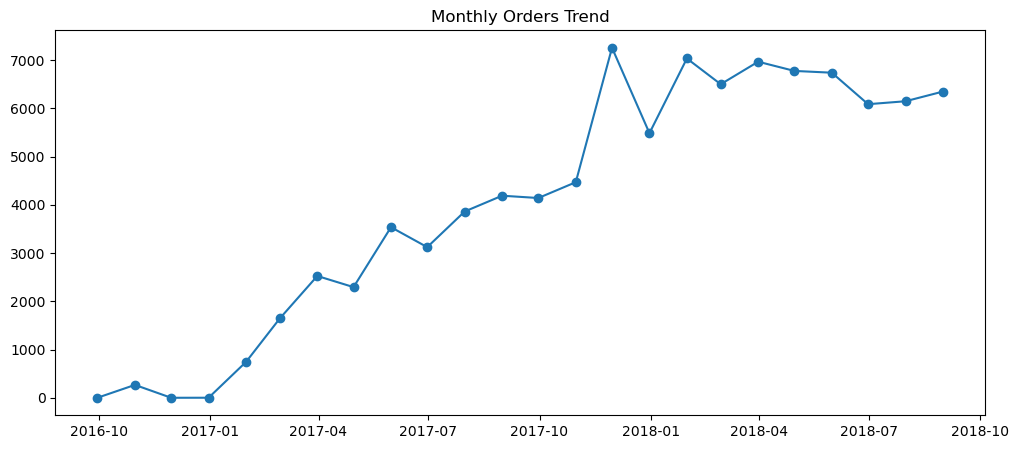

In [783]:
plt.figure(figsize=(12,5))
plt.plot(monthly_df['order_purchase_timestamp'],
         monthly_df['order_id'],
         marker='o')
plt.title("Monthly Orders Trend")
plt.show()

Visualisasi Tren Bulanan Revenue

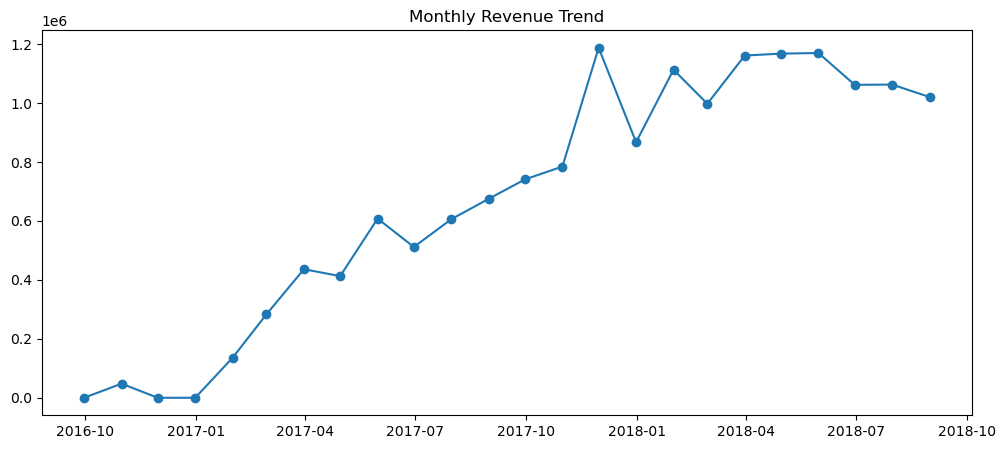

In [784]:
plt.figure(figsize=(12,5))
plt.plot(monthly_df['order_purchase_timestamp'],
         monthly_df['total_price'],
         marker='o')
plt.title("Monthly Revenue Trend")
plt.show()

Hitung total revenue dan jumlah order per kategori

In [785]:

category_perf = all_df.groupby("product_category_name").agg({
    "order_id": "nunique",
    "total_price": "sum"
}).reset_index()

category_perf.columns = ["category", "total_orders", "total_revenue"]

category_perf.head()


,category,total_orders,total_revenue
0,agro_industria_e_comercio,176,85453.45
1,alimentos,436,36232.45
2,alimentos_bebidas,221,20719.26
3,artes,195,28150.71
4,artes_e_artesanato,23,2184.14


##### Menerapkan clustering sederhana berbasis kuartil (quantile binning).

Membuat Revenue Bin per Kategori

In [786]:
category_perf['revenue_bin'] = pd.qcut(
    category_perf['total_revenue'],
    q=4,
    labels=["Low", "Medium", "High", "Top Performer"]
)


Hitung jumlah kategori produk di tiap bin revenue:

In [787]:
category_perf.groupby("revenue_bin")["category"].count()


C:\Users\hpnew\AppData\Local\Temp\ipykernel_19896\2195986292.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_perf.groupby("revenue_bin")["category"].count()


revenue_bin
Low              19
Medium           18
High             18
Top Performer    18
Name: category, dtype: int64

Hitung total revenue dari kategori produk di tiap bin:

In [788]:
category_perf.groupby("revenue_bin")["total_revenue"].sum()

C:\Users\hpnew\AppData\Local\Temp\ipykernel_19896\564480636.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_perf.groupby("revenue_bin")["total_revenue"].sum()


revenue_bin
Low                 70021.03
Medium             523421.05
High              2177722.46
Top Performer    12841679.94
Name: total_revenue, dtype: float64

Visualisasi Distribusi Revenue per Segmen Produk

C:\Users\hpnew\AppData\Local\Temp\ipykernel_19896\1741988979.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = category_perf.groupby("revenue_bin")["total_revenue"].sum().reset_index()


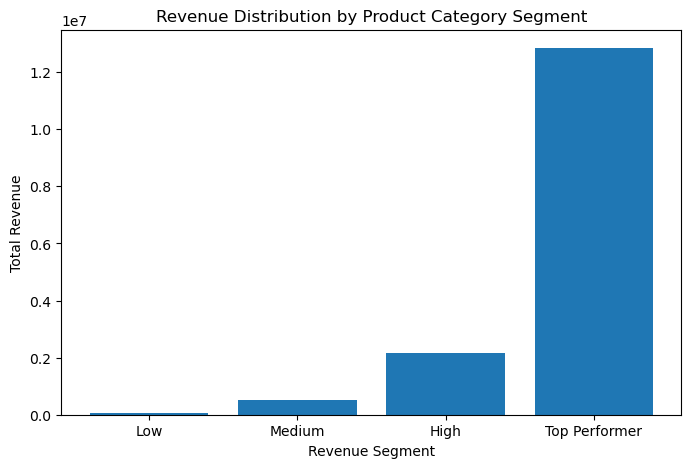

In [789]:
segment_summary = category_perf.groupby("revenue_bin")["total_revenue"].sum().reset_index()

plt.figure(figsize=(8,5))
plt.bar(segment_summary["revenue_bin"], segment_summary["total_revenue"])
plt.title("Revenue Distribution by Product Category Segment")
plt.xlabel("Revenue Segment")
plt.ylabel("Total Revenue")
plt.show()


### Pertanyaan 2: Kategori produk mana yang memiliki jumlah order dan revenue tertinggi selama periode analisis?

Analisis Performa Kategori Produk

In [790]:
category_performance = (
    all_df
    .groupby('product_category_name')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_revenue=('payment_value', 'sum')
    )
    .sort_values(by='total_orders', ascending=False)
)

category_performance.head(10)

,total_orders,total_revenue
product_category_name,,
cama_mesa_banho,9231,1683861.52
beleza_saude,8572,1552125.75
esporte_lazer,7484,1320001.29
informatica_acessorios,6511,1544965.78
moveis_decoracao,6265,1373201.69
utilidades_domesticas,5690,1033153.33
relogios_presentes,5485,1384211.26
telefonia,4084,467986.72
brinquedos,3792,596897.21


Visualisasi Top 10 Kategori Produk Berdasarkan Jumlah Order

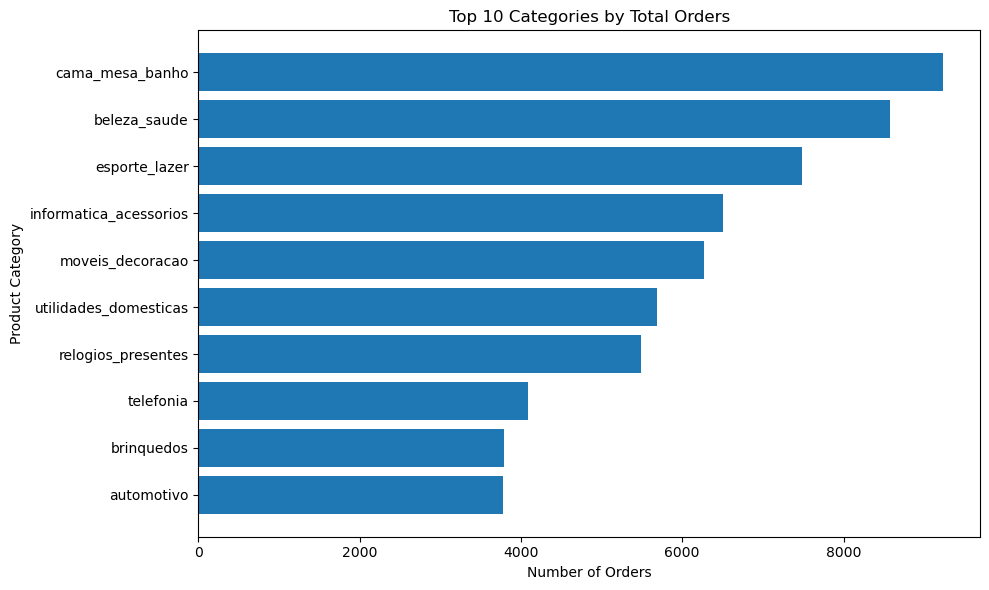

In [791]:
top_orders = category_performance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_orders.index, top_orders['total_orders'])
plt.gca().invert_yaxis()
plt.title("Top 10 Categories by Total Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

Visualisasi Top 10 Kategori Produk Berdasarkan Total Revenue

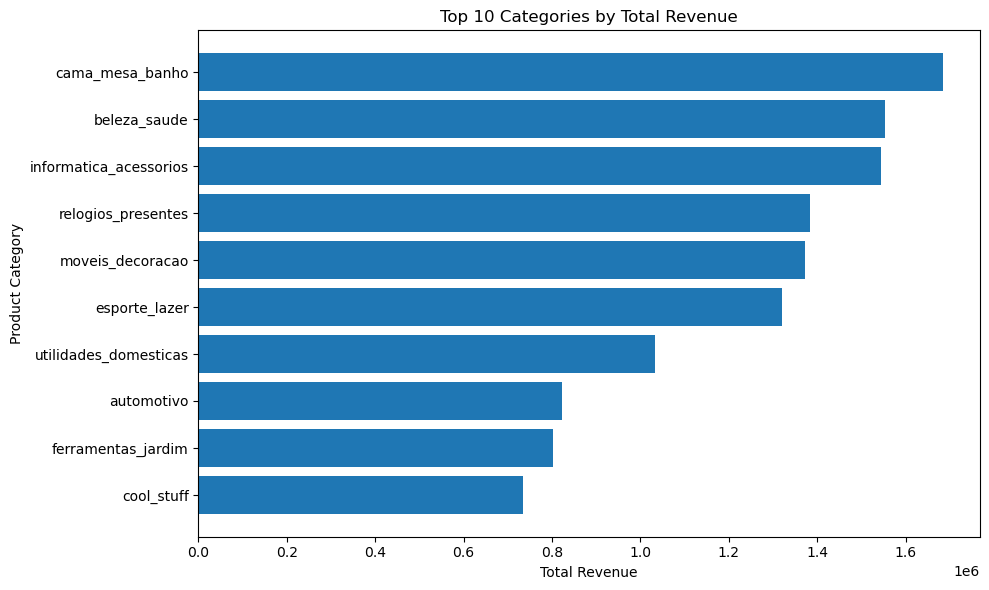

In [792]:
top_revenue = category_performance.sort_values(
    by='total_revenue',
    ascending=False
).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_revenue.index, top_revenue['total_revenue'])
plt.gca().invert_yaxis()
plt.title("Top 10 Categories by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### Pertanyaan 3: Kota mana yang memiliki jumlah order tertinggi dan bagaimana distribusi geografisnya berdasarkan visualisasi peta?

Analisis Kota dengan Order Terbanyak

In [793]:
city_orders = (
    all_df.groupby('customer_city')
    .order_id.nunique()
    .sort_values(ascending=False)
    .head(10)
)

Visualisasi Top 10 Kota Berdasarkan Jumlah Order

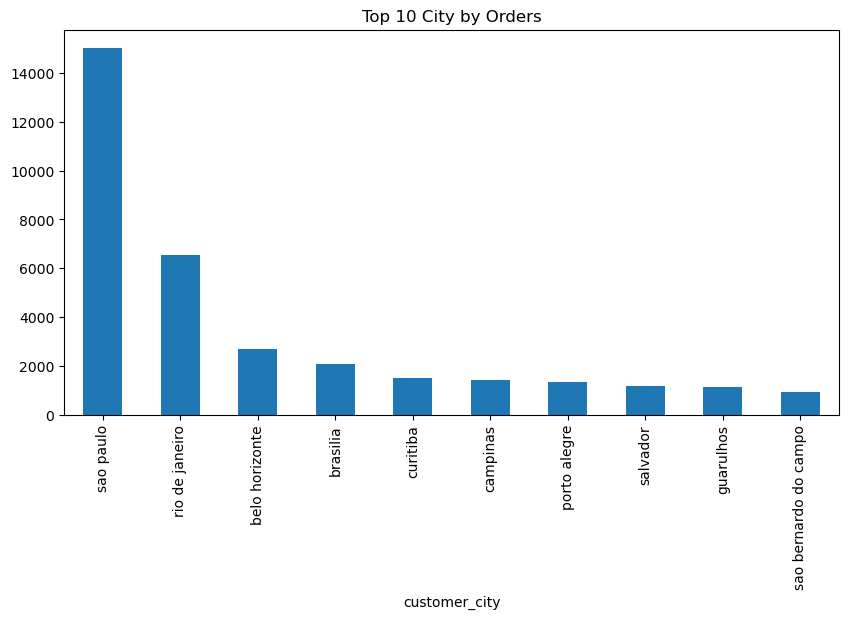

In [794]:
city_orders.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 City by Orders")
plt.show()

Analisis Jumlah Order per Kota

In [795]:
# Merge orders dengan customer
orders_customers = orders.merge(customers, on="customer_id")

# Hitung jumlah order per kota
city_orders = orders_customers.groupby("customer_city")["order_id"].count().reset_index()
city_orders.columns = ["city", "total_orders"]

city_orders = city_orders.sort_values(by="total_orders", ascending=False)

city_orders.head()

,city,total_orders
3556,sao paulo,15028
3120,rio de janeiro,6559
447,belo horizonte,2694
551,brasilia,2070
1133,curitiba,1488


Kota dengan Jumlah Order Terbanyak

In [796]:
top_city = city_orders.iloc[0]
top_city


city            sao paulo
total_orders        15028
Name: 3556, dtype: object

Menyiapkan Data Order per Kota dengan Koordinat

In [797]:
# Ambil rata-rata latitude & longitude per kota
geo_city = all_df.groupby("customer_city")[["geolocation_lat", "geolocation_lng"]].mean().reset_index()

geo_city.columns = ["city", "lat", "lng"]

# Gabungkan dengan data order
city_map_df = city_orders.merge(geo_city, on="city", how="left")

# Hapus data tanpa koordinat
city_map_df = city_map_df.dropna()

city_map_df.head()


,city,total_orders,lat,lng
0,sao paulo,15028,-23.572160,-46.633432
1,rio de janeiro,6559,-22.922775,-43.323059
2,belo horizonte,2694,-19.909761,-43.956521
3,brasilia,2070,-15.809218,-47.975808
4,curitiba,1488,-25.452548,-49.275148


Menerapkan Geospatial Analysis 

Visualisasi Peta Distribusi Order per Kota

In [798]:
# Titik tengah Brazil
m = folium.Map(location=[-14.2350, -51.9253], zoom_start=4)

for _, row in city_map_df.head(100).iterrows():
    
    # Warna berdasarkan volume
    if row["total_orders"] > 5000:
        color = "red"
    elif row["total_orders"] > 2000:
        color = "orange"
    else:
        color = "blue"
    
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=row["total_orders"] / 500,
        popup=f"{row['city']} - Orders: {row['total_orders']}",
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6
    ).add_to(m)

m


### Pertanyaan 3: Bagaimana rata-rata delivery time dan persentase keterlambatan pengiriman selama periode analisis??

Visualisasi Distribusi Waktu Pengiriman

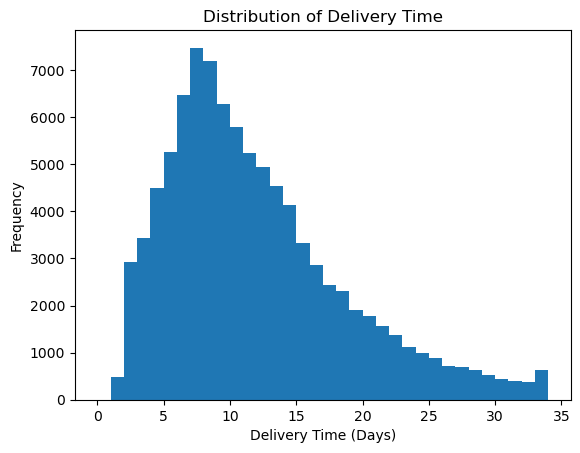

In [799]:
plt.hist(orders["delivery_time"], bins=range(0, 35))
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Frequency")
plt.title("Distribution of Delivery Time")
plt.show()

Visualisasi Proporsi Pengiriman Terlambat

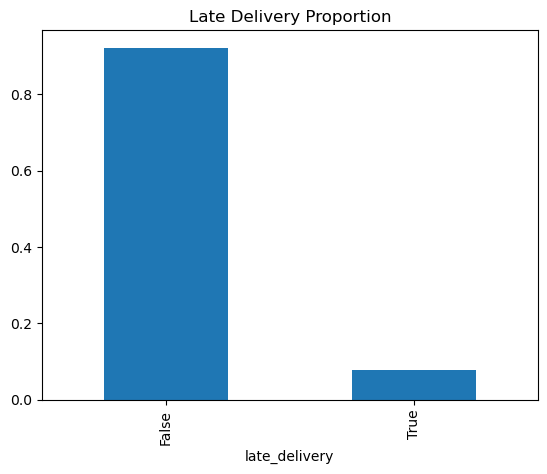

In [800]:
orders['late_delivery'].value_counts(normalize=True).plot(kind='bar')
plt.title("Late Delivery Proportion")
plt.show()

### Pertanyaan 5: Siapa pelanggan terbaik berdasarkan analisis RFM selama periode analisis?

RFM Analysis

In [801]:
rfm_df = all_df.groupby("customer_id", as_index=False).agg({
    "order_purchase_timestamp": "max",   # Recency
    "order_id": "nunique",               # Frequency
    "total_price": "sum"                 # Monetary
})
rfm_df.columns = ["customer_id", "max_order_timestamp", "frequency", "monetary"]

# hitung recency
rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"].dt.date
recent_date = all_df["order_purchase_timestamp"].dt.date.max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)

rfm_df.drop("max_order_timestamp", axis=1, inplace=True)
rfm_df.head()


,customer_id,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,288
1,000161a058600d5901f007fab4c27140,1,67.41,409
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,547
3,0002414f95344307404f0ace7a26f1d5,1,179.35,378
4,000379cdec625522490c315e70c7a9fb,1,107.01,149


Top customer by monetary:

In [802]:
rfm_df.sort_values('monetary', ascending=False).head(10)

,customer_id,frequency,monetary,recency
8276,1617b1357756262bfa56ab541c47bc16,1,13664.08,334
83801,de832e8dbb1f588a47013e53feaa67cc,1,11111.40,457
37347,63b964e79dee32a3587651701a2b8dbf,1,10553.28,196
41629,6f241d5bbb142b6f764387c8c270645a,1,10055.22,111
54958,926b6a6fb8b6081e00b335edaf578d35,1,8389.52,498
88688,eb7a157e8da9c488cd4ddc48711f1097,1,8068.88,85
93736,f959b7bc834045511217e6410985963f,1,8030.46,357
79154,d1ea705f2fdd8f98eff86c2691652e60,1,7413.70,64
89004,ec5b2ba62e574342386871631fafd3fc,1,7274.88,45
18484,3118aefef04e5e97d0e339cd75d6d775,1,7179.97,156


 Visualisasi Top 5 Pelanggan Berdasarkan Monetary Value

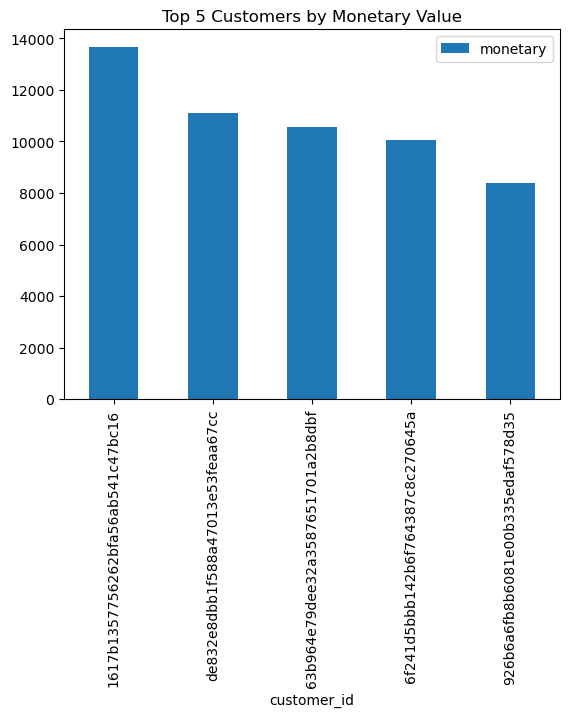

In [803]:
rfm_df.sort_values('monetary', ascending=False)\
      .head(5)\
      .plot(kind='bar', x='customer_id', y='monetary')
plt.title("Top 5 Customers by Monetary Value")
plt.show()

Visualisasi Distribusi RFM Gunakan histogram untuk melihat distribusi Recency, Frequency, dan Monetary:

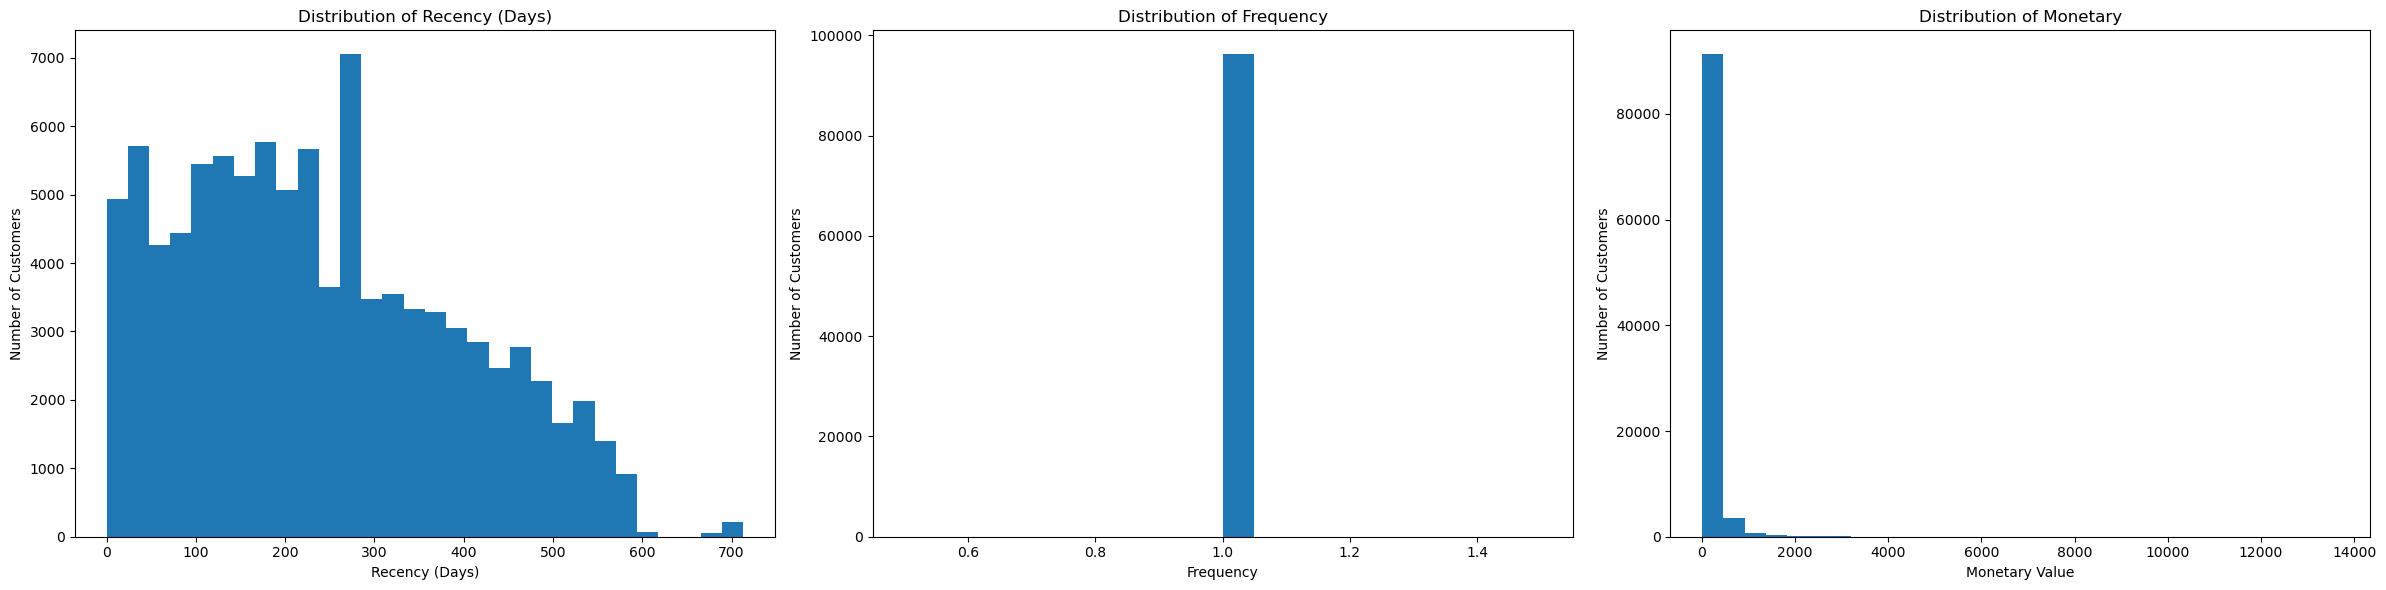

In [804]:


fig, ax = plt.subplots(1, 3, figsize=(24, 6))

# 🔹 Recency
ax[0].hist(rfm_df['recency'], bins=30)
ax[0].set_title("Distribution of Recency (Days)")
ax[0].set_xlabel("Recency (Days)")
ax[0].set_ylabel("Number of Customers")

# 🔹 Frequency
ax[1].hist(rfm_df['frequency'], bins=20)
ax[1].set_title("Distribution of Frequency")
ax[1].set_xlabel("Frequency")
ax[1].set_ylabel("Number of Customers")

# 🔹 Monetary
ax[2].hist(rfm_df['monetary'], bins=30)
ax[2].set_title("Distribution of Monetary")
ax[2].set_xlabel("Monetary Value")
ax[2].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Ranking RFM

In [805]:

rfm_df['r_rank'] = rfm_df['recency'].rank(ascending=False)
rfm_df['f_rank'] = rfm_df['frequency'].rank(ascending=True)
rfm_df['m_rank'] = rfm_df['monetary'].rank(ascending=True)

rfm_df.head()

,customer_id,frequency,monetary,recency,r_rank,f_rank,m_rank
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,288,32866.5,48090.0,51232.0
1,000161a058600d5901f007fab4c27140,1,67.41,409,15985.5,48090.0,27308.0
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,547,2634.5,48090.0,74861.5
3,0002414f95344307404f0ace7a26f1d5,1,179.35,378,20149.5,48090.0,71784.0
4,000379cdec625522490c315e70c7a9fb,1,107.01,149,64405.5,48090.0,48038.0


Normalisasi Ranking RFM

In [806]:

# normalizing the rank of the customers
rfm_df['r_rank_norm'] = (rfm_df['r_rank']/rfm_df['r_rank'].max())*100
rfm_df['f_rank_norm'] = (rfm_df['f_rank']/rfm_df['f_rank'].max())*100
rfm_df['m_rank_norm'] = (rfm_df['m_rank']/rfm_df['m_rank'].max())*100
 
rfm_df.drop(columns=['r_rank', 'f_rank', 'm_rank'], inplace=True)
 
rfm_df.head()

,customer_id,frequency,monetary,recency,r_rank_norm,f_rank_norm,m_rank_norm
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,288,34.173997,100.0,53.267345
1,000161a058600d5901f007fab4c27140,1,67.41,409,16.621436,100.0,28.392892
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,547,2.739306,100.0,77.835598
3,0002414f95344307404f0ace7a26f1d5,1,179.35,378,20.951089,100.0,74.635835
4,000379cdec625522490c315e70c7a9fb,1,107.01,149,66.967684,100.0,49.946454


Skor RFM Gabungan

In [807]:

rfm_df['RFM_score'] = 0.15*rfm_df['r_rank_norm']+0.28 * \
    rfm_df['f_rank_norm']+0.57*rfm_df['m_rank_norm']
rfm_df['RFM_score'] *= 0.05
rfm_df = rfm_df.round(2)
rfm_df[['customer_id', 'RFM_score']].head(7)

,customer_id,RFM_score
0,00012a2ce6f8dcda20d059ce98491703,3.17
1,000161a058600d5901f007fab4c27140,2.33
2,0001fd6190edaaf884bcaf3d49edf079,3.64
3,0002414f95344307404f0ace7a26f1d5,3.68
4,000379cdec625522490c315e70c7a9fb,3.33
5,0004164d20a9e969af783496f3408652,2.34
6,000419c5494106c306a97b5635748086,2.31


Menerapkan manual grouping berbasis aturan RFM score

Segmentasi Pelanggan Berdasarkan Skor RFM

In [808]:

rfm_df["customer_segment"] = np.where(
    rfm_df['RFM_score'] > 4.5, "Top customers", (np.where(
        rfm_df['RFM_score'] > 4, "High value customer",(np.where(
            rfm_df['RFM_score'] > 3, "Medium value customer", np.where(
                rfm_df['RFM_score'] > 1.6, 'Low value customers', 'lost customers'))))))

rfm_df[['customer_id', 'RFM_score', 'customer_segment']].head(10)

,customer_id,RFM_score,customer_segment
0,00012a2ce6f8dcda20d059ce98491703,3.17,Medium value customer
1,000161a058600d5901f007fab4c27140,2.33,Low value customers
2,0001fd6190edaaf884bcaf3d49edf079,3.64,Medium value customer
3,0002414f95344307404f0ace7a26f1d5,3.68,Medium value customer
4,000379cdec625522490c315e70c7a9fb,3.33,Medium value customer
5,0004164d20a9e969af783496f3408652,2.34,Low value customers
6,000419c5494106c306a97b5635748086,2.31,Low value customers
7,00046a560d407e99b969756e0b10f282,3.76,Medium value customer
8,00050bf6e01e69d5c0fd612f1bcfb69c,2.70,Low value customers
9,000598caf2ef4117407665ac33275130,4.95,Top customers


Jumlah Pelanggan per Segmen

In [809]:
customer_segment_df = rfm_df.groupby(by="customer_segment", as_index=False).customer_id.nunique()
customer_segment_df

,customer_segment,customer_id
0,High value customer,15618
1,Low value customers,40471
2,Medium value customer,33662
3,Top customers,5384
4,lost customers,1044


Mengatur Urutan Segmen Pelanggan

In [810]:

customer_segment_df['customer_segment'] = pd.Categorical(customer_segment_df['customer_segment'], [
    "lost customers", "Low value customers", "Medium value customer",
    "High value customer", "Top customers"
])

Visualisasi Jumlah Pelanggan per Segmen

C:\Users\hpnew\AppData\Local\Temp\ipykernel_19896\3679000643.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


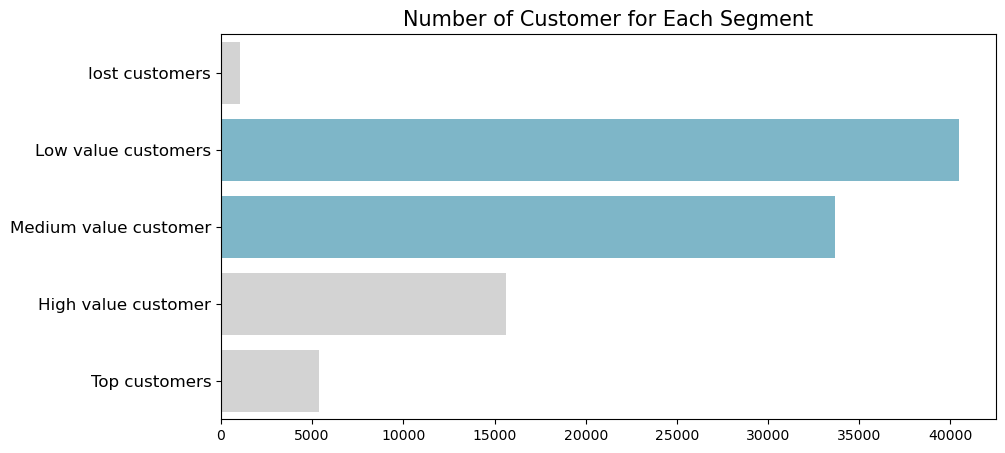

In [811]:

plt.figure(figsize=(10, 5))
colors_ = ["#D3D3D3", "#72BCD4", "#72BCD4", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x="customer_id", 
    y="customer_segment",
    data=customer_segment_df.sort_values(by="customer_segment", ascending=False),
    palette=colors_
)
plt.title("Number of Customer for Each Segment", loc="center", fontsize=15)
plt.ylabel(None)
plt.xlabel(None)
plt.tick_params(axis='y', labelsize=12)
plt.show()

**Insight:**
- Pertanyaan 1: Bagaimana tren jumlah order dan revenue per bulan selama periode analisis?
Analisis visual menunjukkan bahwa sepanjang 2017 bisnis mengalami pertumbuhan jumlah order yang konsisten dengan lonjakan signifikan pada November yang mengindikasikan efek musiman atau kampanye promosi besar, dan pada 2018 volume transaksi tetap stabil di level tinggi sehingga menandakan kemampuan mempertahankan skala pertumbuhan. Pola revenue bergerak selaras dengan jumlah order, di mana peningkatan pendapatan terutama didorong oleh kenaikan volume transaksi, bukan oleh kenaikan harga rata-rata, sehingga ekspansi pasar dan akuisisi customer menjadi motor utama pertumbuhan. Selain itu, segmentasi revenue per kategori (Q1–Q4) memperlihatkan bahwa sebagian kecil kategori berkontribusi secara dominan terhadap total pendapatan, menunjukkan adanya konsentrasi revenue pada produk unggulan; kondisi ini menguntungkan dari sisi fokus strategi, namun juga menimbulkan risiko ketergantungan sehingga diperlukan upaya menjaga performa kategori utama sekaligus mendorong diversifikasi untuk menciptakan pertumbuhan yang lebih berkelanjutan.

- Pertanyaan 2: Kategori produk mana yang memiliki jumlah order dan revenue tertinggi selama periode analisis?
Berdasarkan hasil agregasi dan visualisasi, kategori dengan jumlah order tertinggi adalah cama_mesa_banho (9.231 order), diikuti oleh beleza_saude (8.572) dan esporte_lazer (7.484). Sementara itu, dari sisi total revenue tertinggi juga didominasi oleh cama_mesa_banho (±1,68 juta), diikuti oleh beleza_saude (±1,55 juta) dan informatica_acessorios (±1,54 juta).** Insight pentingnya adalah bahwa cama_mesa_banho tidak hanya unggul dalam volume transaksi tetapi juga dalam kontribusi pendapatan, menunjukkan kombinasi permintaan tinggi dan nilai transaksi yang kuat. Namun, terdapat perbedaan pola antara jumlah order dan revenue pada beberapa kategori, misalnya relogios_presentes dan informatica_acessorios yang memiliki revenue tinggi meskipun jumlah order tidak setinggi tiga besar—mengindikasikan average order value (AOV) yang lebih tinggi. Secara strategis, bisnis memiliki dua tipe kategori unggulan: High volume & high revenue → cama_mesa_banho, beleza_saude (motor utama bisnis). Moderate volume & high revenue → informatica_acessorios, relogios_presentes (bernilai tinggi per transaksi). Ini menunjukkan peluang optimasi berbeda: kategori volume besar cocok untuk strategi promosi mass-market, sedangkan kategori bernilai tinggi cocok untuk strategi margin optimization dan premium positioning.

- Pertanyaan 3: Kota mana yang memiliki jumlah order tertinggi dan bagaimana distribusi geografisnya berdasarkan visualisasi peta?
Berdasarkan visualisasi bar chart dan peta, kota dengan jumlah order tertinggi adalah Sao Paulo dengan total 15.028 order, jauh melampaui kota lainnya seperti Rio de Janeiro (6.559) dan Belo Horizonte (2.694). Secara geografis, distribusi order menunjukkan konsentrasi yang sangat kuat di wilayah Brazil bagian Tenggara (Southeast Region), khususnya di sekitar Sao Paulo dan Rio de Janeiro yang ditandai dengan lingkaran merah berukuran besar pada peta. Kota-kota besar lain seperti Brasília, Curitiba, dan Belo Horizonte juga berkontribusi signifikan, namun skalanya lebih kecil. Pola ini mengindikasikan bahwa aktivitas bisnis sangat terpusat di wilayah metropolitan dan pusat ekonomi utama, sehingga penetrasi pasar masih relatif lebih rendah di wilayah utara dan pedalaman Brazil. Insight ini menunjukkan peluang strategis untuk ekspansi geografis di luar klaster utama sekaligus pentingnya mempertahankan dominasi di kota-kota besar sebagai sumber utama volume transaksi.

- Pertanyaan 4: Bagaimana rata-rata delivery time dan persentase keterlambatan pengiriman selama periode analisis??
Berdasarkan histogram distribusi delivery time, sebagian besar pengiriman berada pada rentang 7–12 hari, dengan puncak frekuensi sekitar 8–10 hari, sehingga rata-rata delivery time dapat disimpulkan berada di kisaran tersebut. Distribusi terlihat right-skewed (miring ke kanan), yang berarti ada sejumlah kecil pengiriman dengan durasi sangat lama (hingga >30 hari) yang memperpanjang ekor distribusi, namun bukan mayoritas kasus.
Dari visualisasi proporsi keterlambatan, sekitar ±90% pengiriman tidak terlambat (False) dan hanya sekitar ±8–10% yang mengalami keterlambatan (True). Ini menunjukkan bahwa performa logistik secara umum sudah cukup baik dan konsisten dalam memenuhi estimasi waktu pengiriman.
Secara keseluruhan, sistem pengiriman tergolong stabil dengan rata-rata waktu sekitar 8–10 hari dan tingkat keterlambatan relatif rendah. Namun, adanya ekor distribusi yang panjang mengindikasikan masih terdapat kasus outlier (pengiriman sangat lama) yang perlu dianalisis lebih lanjut, misalnya berdasarkan lokasi geografis, jenis produk, atau metode pengiriman, untuk meningkatkan efisiensi operasional dan pengalaman pelanggan.

- Pertanyaan 5: Siapa pelanggan terbaik berdasarkan analisis RFM selama periode analisis?
Berdasarkan hasil analisis RFM (Recency, Frequency, Monetary), terlihat bahwa mayoritas pelanggan hanya melakukan satu kali transaksi (frequency = 1), yang menunjukkan tingkat repeat order masih sangat rendah. Distribusi recency yang cukup lebar hingga lebih dari 300 hari juga mengindikasikan banyak pelanggan sudah lama tidak melakukan pembelian kembali, sehingga terdapat potensi churn yang cukup signifikan. Dari sisi monetary, distribusi sangat skewed ke kanan, artinya sebagian besar pelanggan memiliki nilai transaksi kecil, sementara hanya sedikit pelanggan yang berkontribusi dengan nilai belanja sangat tinggi.
Hasil segmentasi menunjukkan bahwa pelanggan didominasi oleh kategori Low Value Customers (40.471 pelanggan), diikuti Medium Value Customer (33.662 pelanggan), sedangkan Top Customers hanya berjumlah 5.384 pelanggan. Meskipun jumlahnya kecil, kelompok Top Customers memiliki kontribusi nilai transaksi paling besar dan berpotensi menjadi penyumbang utama revenue perusahaan. Pola ini menunjukkan adanya ketimpangan kontribusi nilai pelanggan, di mana sebagian kecil pelanggan menghasilkan sebagian besar pendapatan (prinsip Pareto).
Secara keseluruhan, karakteristik pelanggan pada dataset ini menunjukkan bahwa strategi bisnis sebaiknya difokuskan pada peningkatan retensi dan repeat order, karena sebagian besar pelanggan belum menunjukkan loyalitas jangka panjang. Selain itu, perusahaan perlu menjaga dan memberikan perlakuan khusus kepada pelanggan Top Customers agar tetap aktif dan tidak berpindah ke kompetitor, sekaligus mendorong pelanggan Low dan Medium Value untuk meningkatkan frekuensi serta nilai pembelian mereka.


## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1 :
Bagaimana tren jumlah order dan revenue per bulan selama periode analisis?
Bisnis mengalami pertumbuhan jumlah order yang konsisten sepanjang 2017 dengan lonjakan signifikan pada bulan November, kemudian mempertahankan volume transaksi yang stabil pada 2018. Pola revenue bergerak searah dengan jumlah order, sehingga peningkatan pendapatan terutama didorong oleh kenaikan volume transaksi, bukan oleh peningkatan nilai rata-rata per transaksi.

- Conclution pertanyaan 2 :
Kategori produk mana yang memiliki jumlah order dan revenue tertinggi selama periode analisis?
Kategori cama_mesa_banho menjadi kategori dengan jumlah order dan revenue tertinggi selama periode analisis, diikuti oleh beleza_saude dan informatica_acessorios. Hal ini menunjukkan bahwa kategori tersebut memiliki kontribusi dominan terhadap total transaksi dan pendapatan perusahaan.

- Conclution pertanyaan 3 :
Kota mana yang memiliki jumlah order tertinggi selama periode analisis?
Sao Paulo merupakan kota dengan jumlah order tertinggi dan mendominasi secara signifikan dibanding kota lainnya. Distribusi geografis menunjukkan bahwa transaksi terkonsentrasi di wilayah Brazil bagian Tenggara, terutama di kota-kota metropolitan besar.

- Conclution pertanyaan 4 :
Bagaimana rata-rata delivery time dan persentase keterlambatan pengiriman selama periode analisis?
Rata-rata waktu pengiriman berada pada kisaran 8–10 hari dengan mayoritas pengiriman tidak mengalami keterlambatan. Tingkat keterlambatan relatif rendah, menunjukkan performa logistik yang secara umum stabil dan konsisten.

- Conclution pertanyaan 5 :
Siapa pelanggan terbaik berdasarkan analisis RFM selama periode analisis?
Sebagian besar pelanggan hanya melakukan satu kali transaksi dengan distribusi nilai pembelian yang cenderung kecil, sementara hanya sebagian kecil pelanggan yang memiliki kontribusi nilai transaksi tinggi. Segmentasi RFM menunjukkan bahwa pelanggan didominasi oleh kategori Low dan Medium Value, dengan jumlah Top Customers yang relatif lebih sedikit namun memiliki nilai transaksi lebih besar dibanding segmen lainnya.